In [229]:
#Array packages
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4 as nc4

from scipy.stats import kendalltau
import pymannkendall as mk

#plots
import matplotlib.pyplot as plt
import rioxarray as rio
import geopandas as gpd
from shapely.geometry import mapping
import cartopy.crs as ccrs

#Progress meter
from dask.diagnostics import ProgressBar
from tqdm import tqdm

# Directories
import os
import glob
import dask
#import h5netcdf
import scipy

import scipy.stats as stats
import matplotlib.pyplot as plt

import os
#os.chdir(r"G:\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity")
os.chdir(r"E:\academy\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity")

print(os.getcwd())

E:\academy\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity


### 1. Create event binary matrix (Index-dates, columns station)

In [249]:
gauge_final

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,Station,Latitude,Longitude,River Name/ Tributory/ SubTributory,Basin,State,Start_date,End_date,Streamflow_Entries,Privacy,Expected_entries,missing_percent,Period_length
GaugeID,,,,,,,,,,,,,,,,
IWM-gauge-27,0,0,26,Tadipatri,14.9222,78.0028,Pennar,Pennar,Andhra Pradesh,1971-12-12,2017-10-25,16287,Open,16755.0,2.793196,45.904110
IWM-gauge-29,1,1,28,Mantralayam,15.9483,77.4264,Krishna/Tungabha dra,Krishna,Andhra Pradesh,1972-06-01,2019-02-02,16955,Open,17048.0,0.545519,46.706849
IWM-gauge-32,2,2,31,Bawapuram,15.8833,77.9572,Krishna/ Tungabhadra,Krishna,Andhra Pradesh,1965-06-01,2019-02-03,19554,Open,19606.0,0.265225,53.715068
IWM-gauge-54,3,3,53,Keesara,16.7156,80.3164,Krishna/Munneru,Krishna,Andhra Pradesh,1965-01-01,2019-03-20,19760,Open,19802.0,0.212100,54.252055
IWM-gauge-60,4,4,59,Wadenepally,16.7942,80.0692,Krishna,Krishna,Andhra Pradesh,1965-12-01,2019-03-20,19433,Open,19468.0,0.179782,53.336986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
IWM-gauge-997,120,120,996,rishikesh,30.1008,78.3039,Ganga,Ganga - Brahmaputra - Meghna,Uttarakhand,1970-12-05,2011-12-31,15002,Restricted,15002.0,0.000000,41.101370
IWM-gauge-999,121,121,998,uttarkashi,30.7283,78.4461,Ganga/Bhagirath,Ganga - Brahmaputra - Meghna,Uttarakhand,1971-07-15,2011-12-31,14678,Restricted,14780.0,0.690122,40.493151
IWM-gauge-1000,122,122,999,Zero point_tehri,30.3600,78.4800,NaN,Ganga,Uttarakhand,1970-12-03,2011-05-31,14773,Restricted,14790.0,0.114943,40.520548


In [253]:
gauge_final=pd.read_csv(f'3_Data/Data_p/2_Station/1_Streamflow_data/gauge_info_p.csv')
gauge_final.set_index('GaugeID',inplace=True)

dates=pd.date_range(start='1950',end='2020',freq='D')
binary_matrix=pd.DataFrame(np.nan,index=dates,columns=gauge_final.index.values)

for stn in gauge_final.index.values:
    flood_events=pd.read_csv(f'3_Data/Data_p/5_flood events/{stn}.csv')
    binary_matrix.loc[flood_events['Peak Date'],stn]=1

# Calculate ES matrix
ES_matrix=pd.DataFrame(np.nan,index=gauge_final.index.values,columns=gauge_final.index.values)
ES_matrix



,IWM-gauge-27,IWM-gauge-29,IWM-gauge-32,IWM-gauge-54,IWM-gauge-60,IWM-gauge-68,IWM-gauge-113,IWM-gauge-118,IWM-gauge-119,IWM-gauge-121,...,IWM-gauge-983,IWM-gauge-984,IWM-gauge-986,IWM-gauge-989,IWM-gauge-996,IWM-gauge-997,IWM-gauge-999,IWM-gauge-1000,IWM-gauge-1006,IWM-gauge-1078
IWM-gauge-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IWM-gauge-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IWM-gauge-32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IWM-gauge-54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IWM-gauge-60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
IWM-gauge-997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IWM-gauge-999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IWM-gauge-1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IWM-gauge-1006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2 ES algorithm - Method 1

In [ ]:
import itertools
import pandas as pd


combinations = list(itertools.product(gauge_final.index.values, gauge_final.index.values))
df = pd.DataFrame(combinations, columns=["x", "y"])

,x,y
0,IWM-gauge-27,IWM-gauge-27
1,IWM-gauge-27,IWM-gauge-29
2,IWM-gauge-27,IWM-gauge-32
3,IWM-gauge-27,IWM-gauge-54
4,IWM-gauge-27,IWM-gauge-60
...,...,...
15620,IWM-gauge-1078,IWM-gauge-997
15621,IWM-gauge-1078,IWM-gauge-999
15622,IWM-gauge-1078,IWM-gauge-1000
15623,IWM-gauge-1078,IWM-gauge-1006


In [368]:

tau=10
for i in range(len(df)):
    #Clip the common dates
    x=df['x'][i]
    y=df['y'][i]
    clip_st=gauge_final.loc[[x,y],'Start_date'].max()
    clip_end=gauge_final.loc[[x,y],'End_date'].min()
    binary_matrix_clip=binary_matrix.loc[clip_st:clip_end]


    # 1. X synchronization on Y
    event_x=binary_matrix_clip[binary_matrix_clip[x]==1].copy()
    df.loc[i,'sum_x']=event_x[x].sum()

    date_window = sorted(set([d + pd.Timedelta(days=i) for d in event_x.index for i in range(0, tau)])) # Set helps to store only unique date
    datetime_index = pd.DatetimeIndex(date_window)
    xy_forward=binary_matrix.loc[datetime_index,:]

    date_window = sorted(set([d - pd.Timedelta(days=i) for d in event_x.index for i in range(1, tau)])) # Set helps to store only unique date
    datetime_index = pd.DatetimeIndex(date_window)
    xy_backward=binary_matrix.loc[datetime_index,:]

    df.loc[i,'S_xy']=xy_forward[y].sum()+xy_backward[y].sum()


    # 2. Y Synchronization on X
    event_y=binary_matrix_clip[binary_matrix_clip[y]==1].copy()
    df.loc[i,'sum_y']=event_y[y].sum()

    date_window = sorted(set([d + pd.Timedelta(days=i) for d in event_y.index for i in range(0, tau)])) # Set helps to store only unique date
    datetime_index = pd.DatetimeIndex(date_window)
    yx_forward=binary_matrix.loc[datetime_index,:]

    date_window = sorted(set([d - pd.Timedelta(days=i) for d in event_y.index for i in range(1, tau)])) # Set helps to store only unique date
    datetime_index = pd.DatetimeIndex(date_window)
    yx_backward=binary_matrix.loc[datetime_index,:]

    df.loc[i,'S_yx']=yx_forward[x].sum()+yx_backward[x].sum()



    # Total synchornization
    df.loc[i,'ES']=(df.loc[i,'S_xy']+df.loc[i,'S_yx'])/(df.loc[i,'sum_x']+df.loc[i,'sum_y'])

    #Directionality
    df.loc[i,'Directionality']=(xy_forward[y].sum()-yx_forward[x].sum())/(xy_forward[y].sum()+yx_forward[x].sum())

    
    delay=[]
    for x_date in event_x.index:
        date_window = sorted(set([x_date + pd.Timedelta(days=i) for i in range(1 - tau, tau)]))
        
        events=binary_matrix.loc[pd.DatetimeIndex(date_window),:]
        y_date=events[events[y]==1].index
        
        if pd.notna(y_date.mean()):
            delay.append((y_date.mean() - x_date).days)  # sometime more than one event of y will come in the window, so take mean

    # Compute the average delay
    df.loc[i, "Delay"] = np.mean(delay)


df.to_csv(r"2_Analysis\3_Spatial connectivity\Outputs\ES_result1.csv")

C:\Users\sstar\AppData\Local\Temp\ipykernel_14428\1507563592.py:46: RuntimeWarning: invalid value encountered in scalar divide
  df.loc[i,'Directionality']=(xy_forward[y].sum()-yx_forward[x].sum())/(xy_forward[y].sum()+yx_forward[x].sum())
c:\Users\sstar\anaconda3\envs\imed\Lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\sstar\anaconda3\envs\imed\Lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\sstar\AppData\Local\Temp\ipykernel_14428\1507563592.py:46: RuntimeWarning: invalid value encountered in scalar divide
  df.loc[i,'Directionality']=(xy_forward[y].sum()-yx_forward[x].sum())/(xy_forward[y].sum()+yx_forward[x].sum())
c:\Users\sstar\anaconda3\envs\imed\Lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtyp

Timestamp('1973-10-30 12:00:00')

In [347]:
delay

[Index([0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0, 9], dtype='int64'),
 Index([-9, 0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0, 3], dtype='int64'),
 Index([-3, 0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0, 8], dtype='int64'),
 Index([-8, 0, 9], dtype='int64'),
 Index([-9, 0, 9], dtype='int64'),
 Index([-9, 0, 5], dtype='int64'),
 Index([-5, 0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0, 3, 7], dtype='int64'),
 Index([-3, 0, 4], dtype='int64'),
 Index([-7, -4, 0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0], dtype='int64'),
 Index([0, 2, 5], dtype='int64'),
 Index([-2, 0, 3, 9], dtype='int64'),
 Index([-5, -3, 0, 6], dtype='int64'),
 Index([-9, -6

In [ ]:
## # Calculate ES matrix
ES_matrix=pd.DataFrame(np.nan,index=gauge_final.index.values,columns=gauge_final.index.values)
Delay_matrix=pd.DataFrame(np.nan,index=gauge_final.index.values,columns=gauge_final.index.values)

for i in range(len(df)):
    
    ES_matrix.loc[df.loc[i,'x'],df.loc[i,'y']]=df.loc[i,'ES']
    Delay_matrix.loc[df.loc[i,'x'],df.loc[i,'y']]=df.loc[i,'Directionality']

In [308]:
ES_matrix

,IWM-gauge-27,IWM-gauge-29,IWM-gauge-32,IWM-gauge-54,IWM-gauge-60,IWM-gauge-68,IWM-gauge-113,IWM-gauge-118,IWM-gauge-119,IWM-gauge-121,...,IWM-gauge-983,IWM-gauge-984,IWM-gauge-986,IWM-gauge-989,IWM-gauge-996,IWM-gauge-997,IWM-gauge-999,IWM-gauge-1000,IWM-gauge-1006,IWM-gauge-1078
IWM-gauge-27,2.000000,0.251046,0.576923,0.380208,0.425532,0.081633,0.111111,0.147368,0.255034,0.145455,...,0.125000,0.110294,0.194118,0.051020,0.121053,0.134969,0.127168,0.157576,0.048000,0.133333
IWM-gauge-29,0.251046,2.000000,0.933333,0.351254,0.513043,0.330472,0.049383,0.205534,0.132075,0.258772,...,0.231638,0.288557,0.268085,0.333333,0.266667,0.289474,0.205882,0.291304,0.178947,0.089041
IWM-gauge-32,0.576923,0.933333,2.000000,0.561265,0.775510,0.435644,0.111111,0.171296,0.201117,0.306533,...,0.262500,0.390244,0.347368,0.438914,0.386792,0.417989,0.353234,0.442105,0.272109,0.132353
IWM-gauge-54,0.380208,0.351254,0.561265,2.000000,0.440594,0.644231,0.213740,0.402715,0.250000,0.318627,...,0.257669,0.443787,0.548223,0.530973,0.511521,0.494845,0.475728,0.425641,0.243421,0.149254
IWM-gauge-60,0.425532,0.513043,0.775510,0.440594,2.000000,0.435897,0.023529,0.131429,0.130435,0.208861,...,0.247788,0.300813,0.220779,0.174863,0.201149,0.192053,0.134969,0.231788,0.119266,0.040000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
IWM-gauge-997,0.134969,0.289474,0.417989,0.494845,0.192053,0.513158,0.211009,0.368159,0.250000,0.449438,...,0.435484,0.456376,1.118644,0.961905,0.840796,2.000000,1.021277,1.089385,0.500000,0.144068
IWM-gauge-999,0.127168,0.205882,0.353234,0.475728,0.134969,0.432927,0.144068,0.371429,0.207101,0.419355,...,0.413534,0.398734,0.716578,1.036036,1.000000,1.021277,2.000000,1.165775,0.601351,0.147541
IWM-gauge-1000,0.157576,0.291304,0.442105,0.425641,0.231788,0.519481,0.142857,0.264706,0.233129,0.337017,...,0.409449,0.453947,0.740113,1.078431,0.952880,1.089385,1.165775,2.000000,0.681159,0.097561
IWM-gauge-1006,0.048000,0.178947,0.272109,0.243421,0.119266,0.436364,0.000000,0.256250,0.302521,0.233577,...,0.204819,0.361111,0.338129,0.559524,0.540881,0.500000,0.601351,0.681159,2.000000,0.051948


#### Repair works

In [228]:
i=1;j=0
x=gauge_final['GaugeID'][i]
y=gauge_final['GaugeID'][j]

#Clip the common dates
clip_st=gauge_final.loc[[i,j],'Start_date'].max()
clip_end=gauge_final.loc[[i,j],'End_date'].min()
binary_matrix_clip=binary_matrix.loc[clip_st:clip_end]


event_x=binary_matrix_clip[binary_matrix_clip[x]==1].copy()
sum_x=event_x[x].sum()
date_window = sorted(set([d - pd.Timedelta(days=i) for d in event_x.index for i in range(0, tau)])) # Set helps to store only unique date
datetime_index = pd.DatetimeIndex(date_window)


xy_sync_events=binary_matrix.loc[datetime_index,:]  # Here we shouldnt use binary_matrix_clip. Bcoz it will creaete problem when an event comes at last date

xy_sync_events[y].sum()/sum_x

sum_x


206.0

# PLOTs

### 1 Heatmap


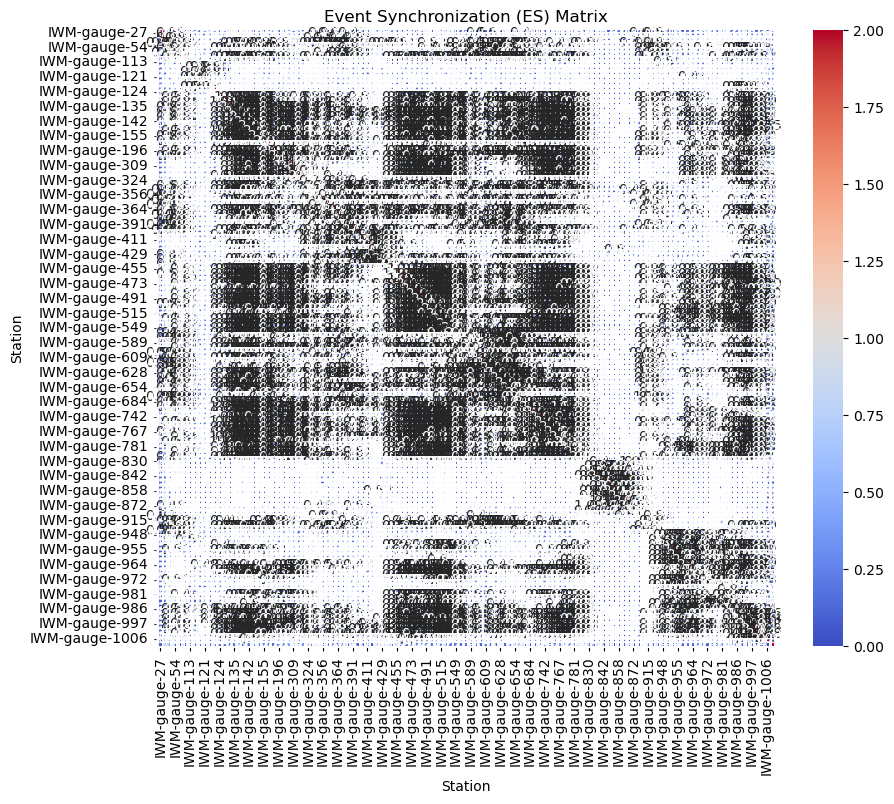

In [309]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(ES_matrix, cmap='coolwarm', annot=True, fmt=".2f", square=True)
plt.title("Event Synchronization (ES) Matrix")
plt.xlabel("Station")
plt.ylabel("Station")
plt.show()


In [317]:
ES_matrix[ES_matrix>1]=0
ES_matrix

,IWM-gauge-27,IWM-gauge-29,IWM-gauge-32,IWM-gauge-54,IWM-gauge-60,IWM-gauge-68,IWM-gauge-113,IWM-gauge-118,IWM-gauge-119,IWM-gauge-121,...,IWM-gauge-983,IWM-gauge-984,IWM-gauge-986,IWM-gauge-989,IWM-gauge-996,IWM-gauge-997,IWM-gauge-999,IWM-gauge-1000,IWM-gauge-1006,IWM-gauge-1078
IWM-gauge-27,0.000000,0.251046,0.576923,0.380208,0.425532,0.081633,0.111111,0.147368,0.255034,0.145455,...,0.125000,0.110294,0.194118,0.051020,0.121053,0.134969,0.127168,0.157576,0.048000,0.133333
IWM-gauge-29,0.251046,0.000000,0.933333,0.351254,0.513043,0.330472,0.049383,0.205534,0.132075,0.258772,...,0.231638,0.288557,0.268085,0.333333,0.266667,0.289474,0.205882,0.291304,0.178947,0.089041
IWM-gauge-32,0.576923,0.933333,0.000000,0.561265,0.775510,0.435644,0.111111,0.171296,0.201117,0.306533,...,0.262500,0.390244,0.347368,0.438914,0.386792,0.417989,0.353234,0.442105,0.272109,0.132353
IWM-gauge-54,0.380208,0.351254,0.561265,0.000000,0.440594,0.644231,0.213740,0.402715,0.250000,0.318627,...,0.257669,0.443787,0.548223,0.530973,0.511521,0.494845,0.475728,0.425641,0.243421,0.149254
IWM-gauge-60,0.425532,0.513043,0.775510,0.440594,0.000000,0.435897,0.023529,0.131429,0.130435,0.208861,...,0.247788,0.300813,0.220779,0.174863,0.201149,0.192053,0.134969,0.231788,0.119266,0.040000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
IWM-gauge-997,0.134969,0.289474,0.417989,0.494845,0.192053,0.513158,0.211009,0.368159,0.250000,0.449438,...,0.435484,0.456376,0.000000,0.961905,0.840796,0.000000,0.000000,0.000000,0.500000,0.144068
IWM-gauge-999,0.127168,0.205882,0.353234,0.475728,0.134969,0.432927,0.144068,0.371429,0.207101,0.419355,...,0.413534,0.398734,0.716578,0.000000,1.000000,0.000000,0.000000,0.000000,0.601351,0.147541
IWM-gauge-1000,0.157576,0.291304,0.442105,0.425641,0.231788,0.519481,0.142857,0.264706,0.233129,0.337017,...,0.409449,0.453947,0.740113,0.000000,0.952880,0.000000,0.000000,0.000000,0.681159,0.097561
IWM-gauge-1006,0.048000,0.178947,0.272109,0.243421,0.119266,0.436364,0.000000,0.256250,0.302521,0.233577,...,0.204819,0.361111,0.338129,0.559524,0.540881,0.500000,0.601351,0.681159,0.000000,0.051948


### 2. Graph plot

In [336]:
gauge_final=pd.read_csv(f'3_Data/Data_p/2_Station/1_Streamflow_data/gauge_info_p.csv')
gauge_final.set_index('GaugeID',inplace=True)
data=gauge_final
data['strength']=ES_matrix.mean(axis=1)
stations=data.index.values
data['strength']


GaugeID
IWM-gauge-27      0.167177
IWM-gauge-29      0.296979
IWM-gauge-32      0.413264
IWM-gauge-54      0.379257
IWM-gauge-60      0.311147
                    ...   
IWM-gauge-997     0.431995
IWM-gauge-999     0.424879
IWM-gauge-1000    0.416869
IWM-gauge-1006    0.280681
IWM-gauge-1078    0.151787
Name: strength, Length: 125, dtype: float64

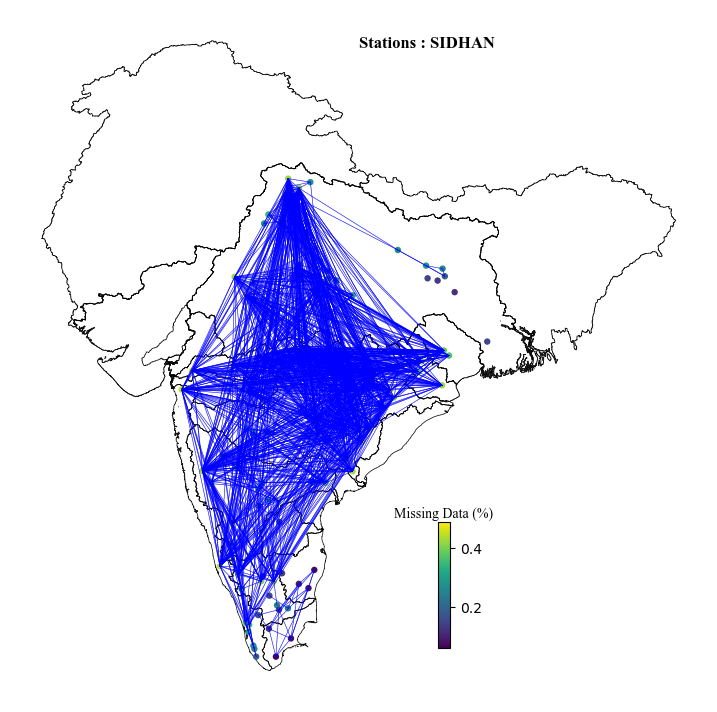

In [370]:
south_asia=gpd.read_file(r'3_Data\Data_p\3_Shapefiles\south_asia_p.shp')

fig, ax1 = plt.subplots(1, 1, figsize=(9,9), subplot_kw={"projection": ccrs.PlateCarree()})
south_asia.plot(ax=ax1,color = 'none',edgecolor = 'black',linewidth=0.55,alpha=0.9)

#Axis setting
[x.set_visible(False) for x in ax1.spines.values()]
[x.set_linewidth(0.2) for x in ax1.spines.values()]



# Edges
c1=np.repeat(['Blue'],len(data['Latitude']))


threshold = 0.55 # Define threshold for strong synchronization
for stn1 in stations:
    for stn2 in stations:
        if stn1 != stn2 and ES_matrix.loc[stn1, stn2] > threshold:
            lon1, lat1 = data.loc[stn1,['Longitude','Latitude']]
            lon2, lat2 = data.loc[stn2,['Longitude','Latitude']]
            ax1.plot([lon1, lon2], [lat1, lat2], color='blue', linewidth=0.4, alpha=0.6)

sc=ax1.scatter(data['Longitude'],data['Latitude'],c=data['strength'],cmap='viridis',s=13,edgecolor=None)

ax1.text(0.50, 0.95, f'Stations : SIDHAN', fontsize=12, color='black',fontname='Times New Roman',weight='bold',
transform=ax1.transAxes, ha='left', va='center')


cbar_ax = fig.add_axes([0.6, 0.17, 0.014, 0.14])
cbar = plt.colorbar(sc, cax=cbar_ax, orientation='vertical', fraction=0.03, pad=0.02)
cbar.ax.set_xlabel('Missing Data (%)', fontsize=10, fontname='Times New Roman')
cbar.ax.xaxis.set_label_position('top')
#cbar.ax.xaxis.set_ticks_position('top')
#plt.savefig(fr'2_Analysis\0_Datapreprocessing\Outputs\{condition}', bbox_inches='tight',dpi=1000)

In [ ]:
import networkx as nx

# Define threshold for strong connectivity
threshold = 0.6  # Adjust based on your dataset

G = nx.DiGraph()  # Directed graph

# Add nodes
stations = list(ES_matrix.index)
for st in stations:
    G.add_node(st)

# Add edges based on ES and delay
for i in range(len(stations)):
    for j in range(len(stations)):
        if i != j and ES_matrix.iloc[i, j] > threshold:
            delay = Delay_matrix.iloc[i, j]
            color = "red" if delay > 0 else "blue"  # Red: A leads B, Blue: B leads A
            G.add_edge(stations[i], stations[j], weight=ES_matrix.iloc[i, j], color=color)

# Draw the network graph
plt.figure(figsize=(10, 8))
edges = G.edges(data=True)
colors = [data['color'] for _, _, data in edges]
pos = nx.spring_layout(G)  # Layout for visualization
nx.draw(G, pos, with_labels=True, edge_color=colors, node_size=500, font_size=10)
plt.title("Event Synchronization Network")
plt.show()
